# 04 — Feedforward Neural Network (PyTorch)

This notebook trains and evaluates the FNN independently from the classical ML models in `03_modeling.ipynb`.

Architecture: `Input(n) → Linear(64) → ReLU → Dropout(0.3) → Linear(32) → ReLU → Dropout(0.3) → Linear(1) → Sigmoid`

Training uses early stopping (patience=10) on an internal 10% validation split.  
The `FNNWrapper` makes the model compatible with `evaluate_model()` and the plot functions.

Results are saved to `outputs/results/metrics.csv`.  
Plots are saved to `outputs/figures/models/`.

## 0 · Imports

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

'''Self modules'''
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.models import split_data, get_X_y
from src.fnn import train_fnn, FNNWrapper
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from config import FEATURE_SETS, FEATURE_CONFIG, FIGURES_MODELS, PLOT_DPI

## 1 · Load & Split

Split is done on the **raw** DataFrame before preprocessing.  
This prevents any data leakage from imputation or encoding statistics.

In [2]:
df_raw = load_data()

df_train_raw, df_test_raw = split_data(df_raw, test_seasons=[2022, 2023])

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
[split_data] Train seasons : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
[split_data] Test  seasons : [np.int32(2022), np.int32(2023)]
[split_data] Train rows    : 286,892
[split_data] Test  rows    : 99,099


## 2 · FNN Feature Set Loop

Train the FNN on all feature sets and collect metrics.  
Detailed plots (training curve, confusion matrix, ROC) are shown inline for the `final` feature set.

**Note:** This will take a few minutes on CPU — consider running on Google Colab for faster results.

In [3]:
# Preprocess the largest feature set once; reuse column subsets to avoid redundant work.
LARGEST_FS = max(FEATURE_SETS, key=lambda k: len(FEATURE_SETS[k]))
_df_train_full = preprocess(df_train_raw, feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)
_df_test_full  = preprocess(df_test_raw,  feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)

# Test auf Train-Spalten alignen (fehlende = 0, extra = gedroppt)
_df_test_full = _df_test_full.reindex(columns=_df_train_full.columns, fill_value=0)


                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 34)
   Features (X): 33 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   down                           | 743          | 0           | 743      | dropped (<1% NaNs)      
   ydstogo                        | 0            | 0           | 0        | -                       
   yardline_100                   | 0            | 0           | 0        | -                       
   goal_to_go                     | 0            | 0           | 0        | -                       
   shotgun                        | 0            | 0           | 0        | -                       
   no_huddle                      | 0       

In [4]:
# updated feature sets with new columns before loop
FEATURE_SETS_ENCODED = {
    fs_name: [
        c for c in _df_train_full.columns
        if c != "target" and any(c == f or c.startswith(f + "_") for f in fs_cols)
    ]
    for fs_name, fs_cols in FEATURE_SETS.items()
}
FEATURE_SETS_ENCODED

{'comprehensive': ['down',
  'ydstogo',
  'yardline_100',
  'goal_to_go',
  'shotgun',
  'no_huddle',
  'score_differential',
  'defteam_score',
  'posteam_timeouts_remaining',
  'defteam_timeouts_remaining',
  'game_seconds_remaining',
  'half_seconds_remaining',
  'qtr',
  'ep',
  'wp',
  'total_line',
  'season_type_REG',
  'drive_start_transition_BLOCKED_FG,_DOWNS',
  'drive_start_transition_BLOCKED_PUNT',
  'drive_start_transition_BLOCKED_PUNT,_DOWNS',
  'drive_start_transition_DOWNS',
  'drive_start_transition_FUMBLE',
  'drive_start_transition_INTERCEPTION',
  'drive_start_transition_KICKOFF',
  'drive_start_transition_MISSED_FG',
  'drive_start_transition_MUFFED_KICKOFF',
  'drive_start_transition_MUFFED_PUNT',
  'drive_start_transition_ONSIDE_KICK',
  'drive_start_transition_OWN_KICKOFF',
  'drive_start_transition_PUNT',
  'roof_dome',
  'roof_open',
  'roof_outdoors']}


 FNN | Feature set: comprehensive  (33 features)
  Epoch  10 | train_loss: 0.5486 | val_loss: 0.5393 | no_improve: 1/10
  Epoch  20 | train_loss: 0.5430 | val_loss: 0.5360 | no_improve: 1/10
  Epoch  30 | train_loss: 0.5398 | val_loss: 0.5335 | no_improve: 0/10
  Epoch  40 | train_loss: 0.5390 | val_loss: 0.5328 | no_improve: 5/10
  Epoch  50 | train_loss: 0.5361 | val_loss: 0.5322 | no_improve: 1/10
  Epoch  59 | train_loss: 0.5359 | val_loss: 0.5328 | no_improve: 10/10

[train_fnn] Early stopping at epoch 59.
[train_fnn] Training complete. Best val_loss: 0.5320
[evaluate_model] Metrics saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\results\metrics.csv

[evaluate_model] FNN | feature_set=comprehensive
  Accuracy  : 0.7195
  F1        : 0.7149
  ROC-AUC   : 0.7873
  Precision : 0.7174
  Recall    : 0.7195

Train NaNs : 0
Test  NaNs : 0
Train shape: (203362, 34)
Test  shape: (70778, 34)
Target distribution (train):
target
1    0.591
0    0.409
Name: p

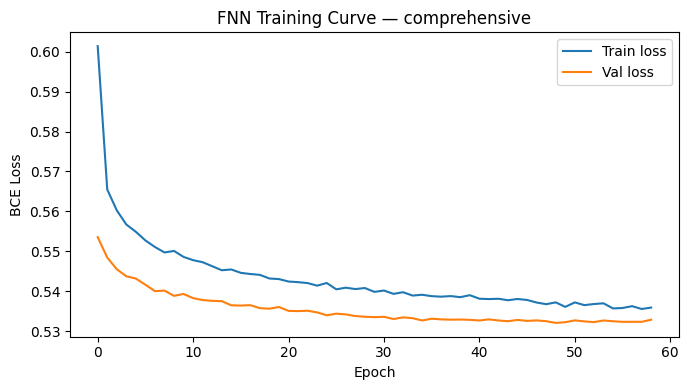

Saved → C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\fnn_training_curve_comprehensive.png
[plot_confusion_matrix] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\cm_FNN_comprehensive.png
[plot_roc_curve] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\roc_comprehensive.png

Done. FNN results saved to metrics.csv


In [5]:
for fs_name, fs_cols in FEATURE_SETS_ENCODED.items():

    print(f"\n{'='*55}")
    print(f" FNN | Feature set: {fs_name}  ({len(fs_cols)} features)")
    print(f"{'='*55}")

    is_subset = all(c in _df_train_full.columns for c in fs_cols)
    if is_subset:
        _df_train = _df_train_full[fs_cols + ["target"]]
        _df_test  = _df_test_full[fs_cols  + ["target"]]
    else:
        _df_train = preprocess(df_train_raw, feature_set=fs_cols, feature_config=FEATURE_CONFIG)
        _df_test  = preprocess(df_test_raw,  feature_set=fs_cols, feature_config=FEATURE_CONFIG)

    _X_train, _y_train = get_X_y(_df_train)
    _X_test,  _y_test  = get_X_y(_df_test)

    _fnn_model, _fnn_history, _fnn_scaler = train_fnn(
        X_train=_X_train,
        y_train=_y_train,
        val_split=0.1,
        epochs=100,
        batch_size=512,
        lr=3e-4,
        patience=10,
    )
    _fnn_wrapper = FNNWrapper(_fnn_model, scaler=_fnn_scaler)

    evaluate_model(_fnn_wrapper, _X_test, _y_test, "FNN", fs_name)


    # Sanity check
    print(f"Train NaNs : {_df_train.isna().sum().sum()}")
    print(f"Test  NaNs : {_df_test.isna().sum().sum()}")
    print(f"Train shape: {_df_train.shape}")
    print(f"Test  shape: {_df_test.shape}")
    print(f"Target distribution (train):\n{_df_train['target'].value_counts(normalize=True).round(3)}")

    # Training curve
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(_fnn_history["train_loss"], label="Train loss")
    ax.plot(_fnn_history["val_loss"],   label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title(f"FNN Training Curve — {fs_name}")
    ax.legend()
    fig.tight_layout()
    FIGURES_MODELS.mkdir(parents=True, exist_ok=True)
    save_path = FIGURES_MODELS / f"fnn_training_curve_{fs_name}.png"
    fig.savefig(save_path, dpi=PLOT_DPI)
    plt.show()
    print(f"Saved → {save_path}")

    # Confusion matrix
    plot_confusion_matrix(_fnn_wrapper, _X_test, _y_test, "FNN", fs_name)

    # ROC curve
    plot_roc_curve(
        models={"FNN": _fnn_wrapper},
        X_test=_X_test,
        y_test=_y_test,
        feature_set=fs_name,
    )

print("\nDone. FNN results saved to metrics.csv")